# 05 - Model Evaluation
## Fake News Detection - Performance Analysis

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    confusion_matrix, classification_report,
    roc_curve, auc, precision_recall_curve
)
import joblib
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-darkgrid')
%matplotlib inline

In [3]:
# Load model and data
model = joblib.load('../webapp/model/logistic_regression_model.pkl')

# Load test data
test_data = np.load('../data/test_tfidf.npz')
X_test = test_data['arr_0']

import pickle
with open('../data/train_test_data.pkl', 'rb') as f:
    data = pickle.load(f)
    y_test = data['y_test']

# Predictions
y_pred = model.predict(X_test)
y_pred_proba = model.predict_proba(X_test)[:, 1]

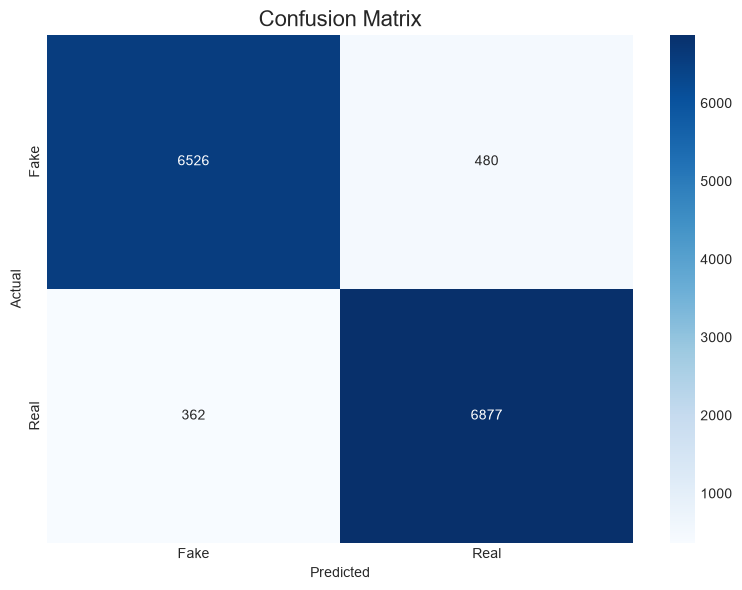

In [4]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=['Fake', 'Real'],
            yticklabels=['Fake', 'Real'])
ax.set_title('Confusion Matrix', fontsize=16)
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
plt.tight_layout()
plt.show()

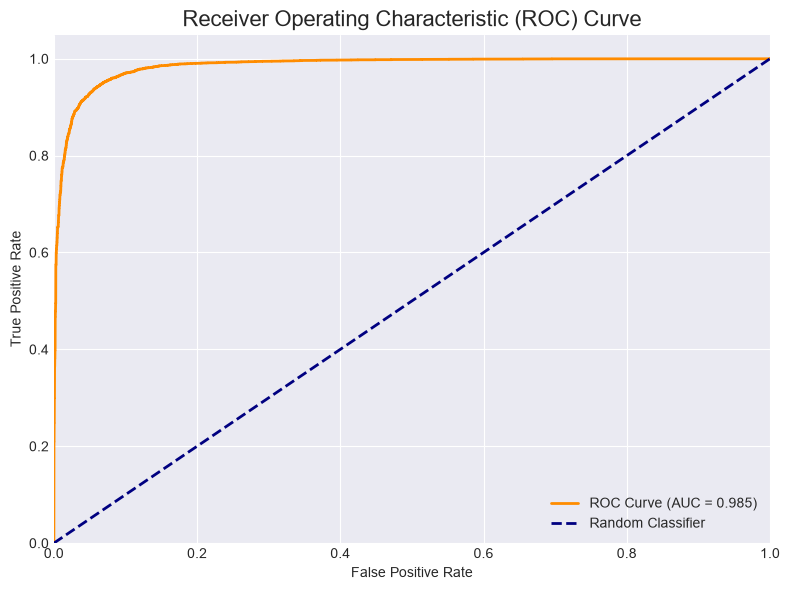

In [5]:
# ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
roc_auc = auc(fpr, tpr)

fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC Curve (AUC = {roc_auc:.3f})')
ax.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Classifier')
ax.set_xlim([0.0, 1.0])
ax.set_ylim([0.0, 1.05])
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('Receiver Operating Characteristic (ROC) Curve', fontsize=16)
ax.legend(loc='lower right')
ax.grid(True)
plt.tight_layout()
plt.show()

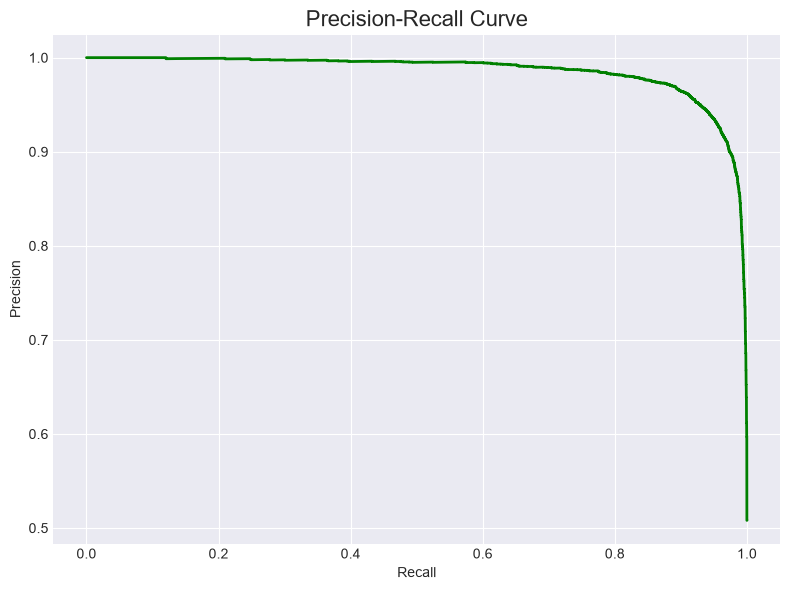

In [6]:
# Precision-Recall Curve
precision, recall, _ = precision_recall_curve(y_test, y_pred_proba)

fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(recall, precision, color='green', lw=2)
ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
ax.set_title('Precision-Recall Curve', fontsize=16)
ax.grid(True)
plt.tight_layout()
plt.show()

In [7]:
# Classification Metrics
print("="*60)
print("CLASSIFICATION METRICS")
print("="*60)
print(classification_report(y_test, y_pred, target_names=['Fake (0)', 'Real (1)']))

tn, fp, fn, tp = cm.ravel()
print("\nAdditional Metrics:")
print(f"Accuracy: {(tp+tn)/(tp+tn+fp+fn):.4f}")
print(f"Precision (Fake): {tn/(tn+fn):.4f}")
print(f"Recall (Fake): {tn/(tn+fp):.4f}")
print(f"Precision (Real): {tp/(tp+fp):.4f}")
print(f"Recall (Real): {tp/(tp+fn):.4f}")
print(f"F1-Score (Fake): {2*(tn/(tn+fn))*(tn/(tn+fp))/((tn/(tn+fn))+(tn/(tn+fp))):.4f}")
print(f"F1-Score (Real): {2*(tp/(tp+fp))*(tp/(tp+fn))/((tp/(tp+fp))+(tp/(tp+fn))):.4f}")

CLASSIFICATION METRICS
              precision    recall  f1-score   support

    Fake (0)       0.95      0.93      0.94      7006
    Real (1)       0.93      0.95      0.94      7239

    accuracy                           0.94     14245
   macro avg       0.94      0.94      0.94     14245
weighted avg       0.94      0.94      0.94     14245


Additional Metrics:
Accuracy: 0.9409
Precision (Fake): 0.9474
Recall (Fake): 0.9315
Precision (Real): 0.9348
Recall (Real): 0.9500
F1-Score (Fake): 0.9394
F1-Score (Real): 0.9423


In [9]:
# Save evaluation results
results = {
    'accuracy': (tp+tn)/(tp+tn+fp+fn),
    'roc_auc': roc_auc,
    'precision_fake': tn/(tn+fn),
    'recall_fake': tn/(tn+fp),
    'precision_real': tp/(tp+fp),
    'recall_real': tp/(tp+fn)
}

pd.DataFrame([results]).to_csv('../webapp/model/evaluation_results.csv', index=False)
print("\n✅ Evaluation results saved to '../models/evaluation_results.csv'")


✅ Evaluation results saved to '../models/evaluation_results.csv'
